In [1]:
%matplotlib inline

import numpy as np
import visualization as vs
import util as ut
import matplotlib.pyplot as plt
import pandas as pd
import MDP_algorithms.mdp_state_action as mdp
import MDP_algorithms.value_iteration as vi
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import potential_games as game
import time
from itertools import product
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
import tracemalloc

from global_util import Global_MDP
from global_util_augmented import Global_MDP_aug

Starting joint MDP construction...
----------------------------------------
Target nodes: [0 3]
Starting nodes: [3 0]
Time to construct sparse joint P: 0.0 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.0 seconds.
Potential value: 0.6642000000000001
Collision Likelihood 0.3275999999999999


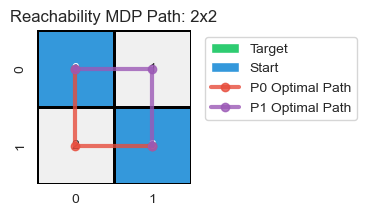

Joint occupancy propagation complete.


<Figure size 640x480 with 0 Axes>

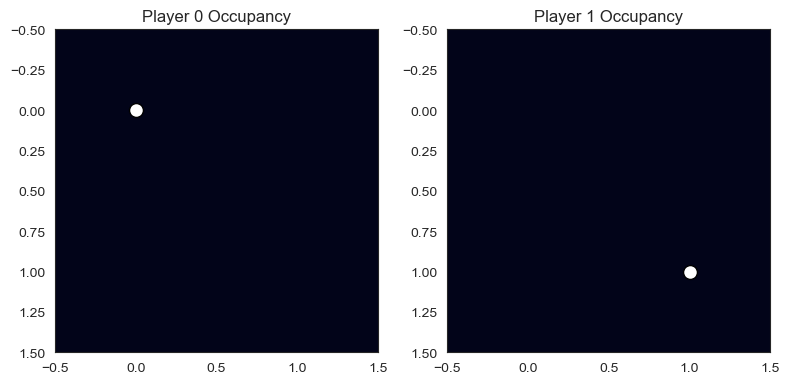

Animation saved as mdp_animation_2x2.gif


In [4]:
#------------------------------------------------
# Verify: Global metrics are implemented correctly, 
#         Single or two player for two cases where 
#         you know the occupancy measure. 
#------------------------------------------------

Columns = 2
Rows = 2
T = 2
player_num = 2
action_entropy = 0.9
targs_x0s = np.array([0,3,3,0])

test = Global_MDP(Rows,Columns,T,player_num)
test.create_joint_MDP(action_entropy, targs_x0s)
test.global_value_iteration()
test.get_potential()
print('Potential value:', test.potential_value)
test.get_collision_likelihood()
print('Collision Likelihood',test.collision_likelihood)
# test.get_reach_reduction()
# print('Reach reduction:',test.reach_reduction)
test.highest_prob_trajectory()
test.plot_occupancy_grid()
plt.savefig('2x2grid')


my_ani = test.animate_occupancy()
my_ani.save('mdp_animation_2x2.gif', writer='pillow', fps=2)
print("Animation saved as mdp_animation_2x2.gif")

Starting joint MDP construction...
----------------------------------------
Target nodes: [0 2]
Starting nodes: [6 8]
Time to construct sparse joint P: 0.02 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.08 seconds.
Potential value: 0.9165030524999999
Collision Likelihood 0.01405418843750006
Reach reduction: 0.9864383661961513


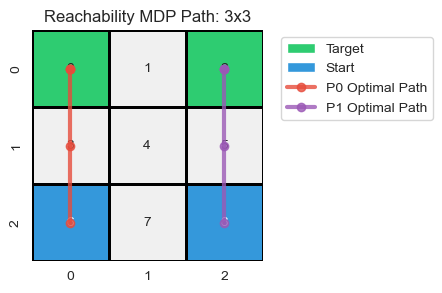

[(6, 8), (3, 5), (0, 2), (0, 2), (0, 2)]

In [17]:
#------------------------------------------------
# Verify: Global metrics: If I gave two trajectories that are parallel vs trajs that are normal, 
# what should they look like? Come up with test cases.
#------------------------------------------------

Columns = 3
Rows = 3
T = 4
player_num = 2

action_entropy = 0.9
targs_x0s_parallel = np.array([0,2,6,8])

test_parallel = Global_MDP(Rows,Columns,T,player_num)
test_parallel.create_joint_MDP(action_entropy, targs_x0s_parallel)

test_parallel.global_value_iteration()

test_parallel.get_potential()
print('Potential value:', test_parallel.potential_value)
test_parallel.get_collision_likelihood()
print('Collision Likelihood',test_parallel.collision_likelihood)
test_parallel.get_reach_reduction()
print('Reach reduction:',test_parallel.reach_reduction)

test_parallel.highest_prob_trajectory()
test_parallel.plot_occupancy_grid()
test_parallel.traj

Starting joint MDP construction...
----------------------------------------
Target nodes: [0 2]
Starting nodes: [2 0]
Time to construct sparse joint P: 0.02 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.09 seconds.
Potential value: 0.6325357226666669
Collision Likelihood 0.16521668298271575
Reach reduction: 0.8349246683967707


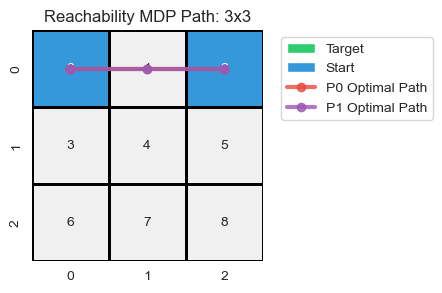

Starting joint MDP construction...
----------------------------------------
Target nodes: [0 2]
Starting nodes: [2 0]
Time to construct sparse joint P: 0.02 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.1 seconds.
Potential value: 0.5434944284444447
Collision Likelihood 0.05052448564938239
Reach reduction: 0.717393325283545


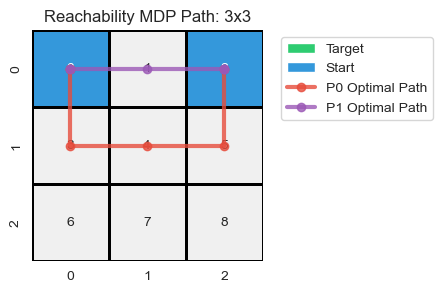

[(2, 0), (5, 0), (4, 1), (3, 2), (0, 2), (0, 2)]

In [2]:
Columns = 3
Rows = 3
T = 5
player_num = 2
action_entropy = 0.8


targs_x0s_normal = np.array([0,2,2,0])

test_normal = Global_MDP(Rows,Columns,T,player_num)
test_normal.create_joint_MDP(action_entropy, targs_x0s_normal)

test_normal.global_value_iteration()

test_normal.get_potential()
print('Potential value:', test_normal.potential_value)
test_normal.get_collision_likelihood()
print('Collision Likelihood',test_normal.collision_likelihood)
test_normal.get_reach_reduction()
print('Reach reduction:',test_normal.reach_reduction)

test_normal.highest_prob_trajectory()
test_normal.plot_occupancy_grid()
test_normal.traj

test_normal_aug = Global_MDP_aug(Rows,Columns,T,player_num,0.0)
test_normal_aug.create_joint_MDP(action_entropy, targs_x0s_normal)

test_normal_aug.global_value_iteration()

test_normal_aug.get_potential()
print('Potential value:', test_normal_aug.potential)
test_normal_aug.get_collision_likelihood()
print('Collision Likelihood',test_normal_aug.collision_likelihood)
test_normal_aug.get_reach_reduction()
print('Reach reduction:',test_normal_aug.reach_reduction)

test_normal_aug.highest_prob_trajectory()
test_normal_aug.plot_occupancy_grid()
test_normal_aug.traj



Starting joint MDP construction...
----------------------------------------
Target nodes: [0 3]
Starting nodes: [15 12]
Time to construct sparse joint P: 0.01 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 5 ...
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.84 seconds.
Potential value: 1.0
Collision Likelihood 0.0
Reach reduction: 1.0


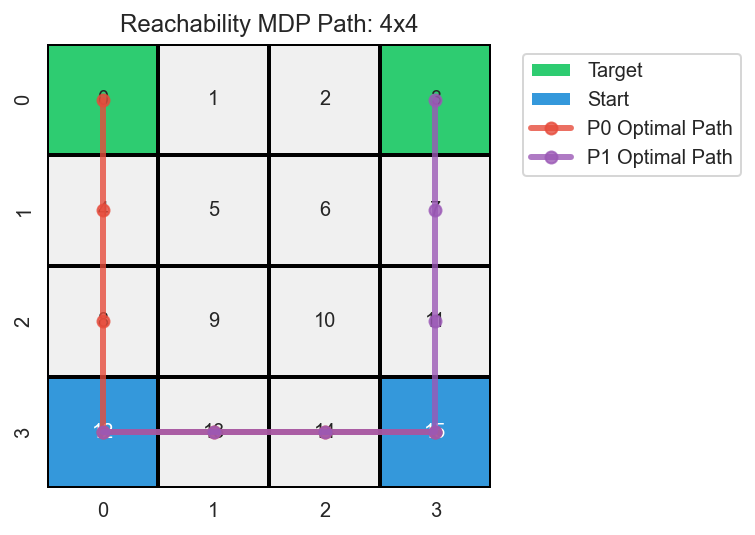

[(15, 12), (14, 13), (13, 14), (12, 15), (8, 11), (4, 7), (0, 3)]

In [13]:
#------------------------------------------------
# Verify: that the single player is going to the goal and the two player is avoiding each other
# Compute highest probability of being in a state at time t
#------------------------------------------------

# Targets and initial conditions in opposite corners

Columns = 4
Rows = 4
T = 6
player_num = 2

action_entropy = 1.0
targs_x0s = np.array([0,3,15,12])

test = Global_MDP(Rows,Columns,T,player_num)
test.create_joint_MDP(action_entropy, targs_x0s)

test.global_value_iteration()

test.get_potential()
print('Potential value:', test.potential_value)
test.get_collision_likelihood()
print('Collision Likelihood',test.collision_likelihood)
test.get_reach_reduction()
print('Reach reduction:',test.reach_reduction)

test.highest_prob_trajectory()
test.plot_occupancy_grid()
test.traj

In [ ]:
#------------------------------------------------
# Compute Occupancy: heatmap of occupancy measures as a function of timestep -> animation per timestep t
#------------------------------------------------

# I have this as an animation


Starting joint MDP construction...
----------------------------------------
Target nodes: [0 3]
Starting nodes: [10 12]
Time to construct sparse joint P: 0.05 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 9 ...
Calculating for timestep 8 ...
Calculating for timestep 7 ...
Calculating for timestep 6 ...
Calculating for timestep 5 ...
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 1.76 seconds.
Potential value: 0.8643945592113008
Collision Likelihood 0.006104636269764652
Reach reduction: 0.9981967865892982


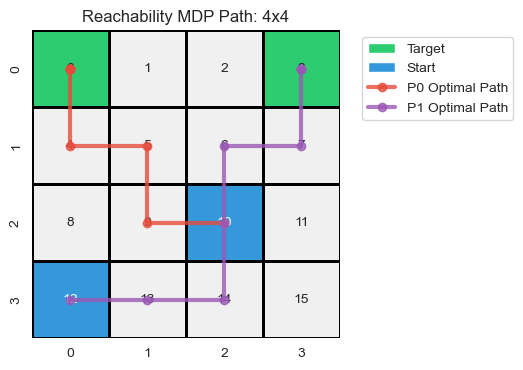

Global Trajectory: [(10, 12), (9, 13), (5, 14), (4, 10), (0, 6), (0, 7), (0, 3), (0, 3), (0, 3), (0, 3), (0, 3)]


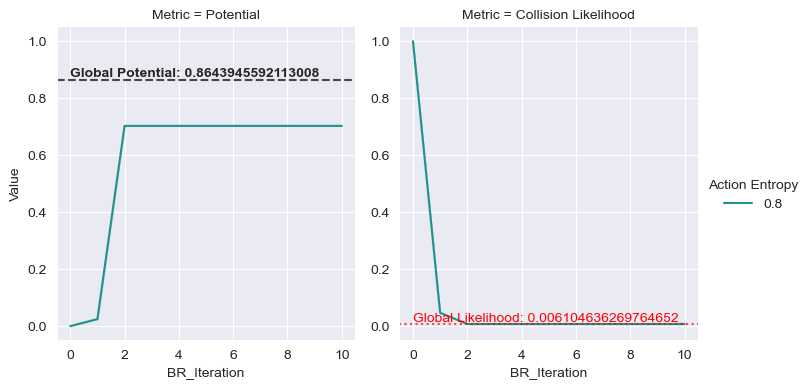

Joint occupancy propagation complete.


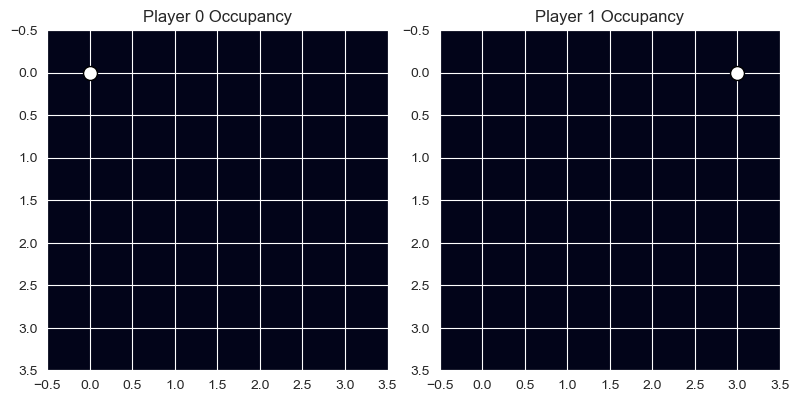

Animation saved as mdp_animation.gif


In [18]:
# Comparison of Global Feedback and Local Feedback Policies
# EXAMPLE 1:

import importlib
demo = importlib.import_module("2p_demo_class")
local_feedback_policy = demo.local_feedback_policy

#------------------------------------------------------------
Columns = 4
Rows = 4
T = 10
player_num = 2

action_entropy = 0.8
targs_x0s = np.array([0,3,10,12])

test = Global_MDP(Rows,Columns,T,player_num)
test.create_joint_MDP(action_entropy, targs_x0s)

test.global_value_iteration()

test.get_potential()
test.get_collision_likelihood()
test.get_reach_reduction()

pot = test.potential_value
coll = test.collision_likelihood
reach = test.reach_reduction

print('Potential value:', pot)
print('Collision Likelihood',coll)
print('Reach reduction:',reach)

test.highest_prob_trajectory()
test.plot_occupancy_grid()
print('Global Trajectory:',test.traj)
#------------------------------------------------------------



trial_data = local_feedback_policy(Rows,Columns,T,player_num,targs_x0s,action_entropy)

# 1. Set the aesthetic style
sns.set_style("darkgrid")


g = sns.relplot(
    data=trial_data,
    kind="line",
    x="BR_Iteration", 
    y="Value", 
    hue="Action Entropy",
    col="Metric",
    height=4, 
    aspect=0.9,
    facet_kws={'sharey': False},  # Allows Potential and Collision to have different Y scales
    palette="viridis"             # Good for sequential data like 'Action Entropy'
)

for ax in g.axes.flat:
    ax.set_ylim(-0.05, 1.05)                          

g.axes[0, 0].axhline(pot, color='black', ls='--', alpha=0.7)
g.axes[0, 0].text(0, pot, f'Global Potential: {pot}', va='bottom', fontweight='bold')

# Plot 2 (Collision)
g.axes[0, 1].axhline(coll, color='red', ls=':', alpha=0.7)
g.axes[0, 1].text(0, coll, f'Global Likelihood: {coll}', va='bottom', color='red')

plt.show()


my_ani = test.animate_occupancy()
my_ani.save('mdp_animation.gif', writer='pillow', fps=2)
print("Animation saved as mdp_animation.gif")

Starting joint MDP construction...
----------------------------------------
Target nodes: [0 2]
Starting nodes: [8 6]
Time to construct sparse joint P: 0.02 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 5 ...
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.12 seconds.
Starting joint MDP construction...
----------------------------------------
Target nodes: [0 2]
Starting nodes: [8 6]
Time to construct sparse joint P: 0.01 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 5 ...
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.11 seconds.
Starting joint MDP construction...
-----

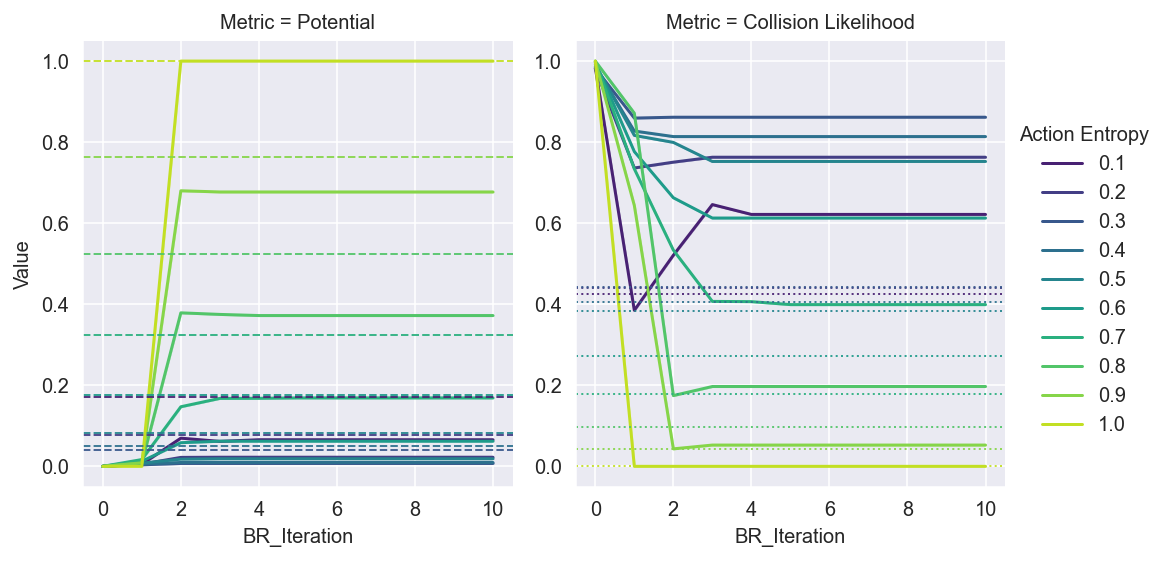

In [9]:
# Comparison of Global Feedback and Local Feedback Policies
# EXAMPLE 2:

import importlib
demo = importlib.import_module("2p_demo_class")
local_feedback_policy = demo.local_feedback_policy

#------------------------------------------------------------
Columns = 3
Rows = 3
T = 6
player_num = 2

change_entropy = [0.1*(i+1) for i in range(10)]

all_trial_results = []
global_baselines = {} 

targs_x0s = np.array([0,2,8,6])

for action_entropy in change_entropy:
    
    test = Global_MDP(Rows,Columns,T,player_num)
    test.create_joint_MDP(action_entropy, targs_x0s)
    test.global_value_iteration()
    test.get_potential()
    test.get_collision_likelihood()

    global_baselines[round(action_entropy, 2)] = {
        'pot': test.potential_value,
        'coll': test.collision_likelihood
    }
    

    trial_data = local_feedback_policy(Rows, Columns, T, player_num, targs_x0s, action_entropy)

    all_trial_results.append(trial_data)


master_data = pd.concat(all_trial_results, ignore_index=True)


unique_entropies = [str(round(e, 2)) for e in change_entropy]
colors = sns.color_palette("viridis", len(unique_entropies))
entropy_to_color = dict(zip(unique_entropies, colors))

sns.set_style("darkgrid")

g = sns.relplot(
    data=master_data,
    kind="line",
    x="BR_Iteration", 
    y="Value", 
    hue="Action Entropy",
    hue_order=unique_entropies,
    col="Metric",
    height=4, 
    aspect=0.9,
    facet_kws={'sharey': False},
    palette=entropy_to_color #
)

for entropy_str, color in entropy_to_color.items():

    e_key = float(entropy_str)
    vals = global_baselines[e_key]
    

    g.axes[0, 0].axhline(vals['pot'], color=color, ls='--', alpha=0.9, linewidth=1)
    g.axes[0, 1].axhline(vals['coll'], color=color, ls=':', alpha=0.9, linewidth=1)

for ax in g.axes.flat:
    ax.set_ylim(-0.05, 1.05)

plt.show()

In [ ]:
# COMMENTS ON EXISTING LOCAL POLICY FEEDBACK
#------------------------------------------------
# Should line 141 be using the new player rho?
#------------------------------------------------

# No, new_rho is not even initialized before this function. It retur

#------------------------------------------------
# For loop starting at line 113 should contain some condition for collisions, account for Y
#------------------------------------------------

# Short answer is yes, that the Y condition in line 85 is accounting for the collisions in the loop starting at line 113. 
# If there is a collision, the eV is not updated and treated as a 0. This means that whenever a collision is detected there will be
# zero in the corresponding index for the value matrix.


Starting joint MDP construction...
----------------------------------------
Target nodes: [0 3]
Starting nodes: [3 0]
Time to construct sparse joint P: 0.01 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.02 seconds.
Global Policy Peak Memory: 0.07 MB
Local Policy Peak Memory: 0.63 MB


In [26]:
#------------------------------------------------
# Look into memory: smaller state 5x5:
#------------------------------------------------

tracemalloc
Columns = 5
Rows = 5
T = 5
player_num = 2
action_entropy = 1.0
targs_x0s = np.array([0,3,3,0])

test = Global_MDP(Rows,Columns,T,player_num)

def run_global():
    test.create_joint_MDP(action_entropy, targs_x0s)
    test.global_value_iteration()
    return test

_, global_mem = measure_memory(run_global)
print(f"Global Policy Peak Memory: {global_mem:.2f} MB")

_, local_mem = measure_memory(
    local_feedback_policy, Rows, Columns, T, player_num, targs_x0s, action_entropy
)
print(f"Local Policy Peak Memory: {local_mem:.2f} MB")

Starting joint MDP construction...
----------------------------------------
Target nodes: [0 3]
Starting nodes: [3 0]
Time to construct sparse joint P: 0.36 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 65.54 seconds.
Global Policy Peak Memory: 3.72 MB
Local Policy Peak Memory: 0.67 MB


In [ ]:
# Idea: Plot memory as a function of state size, memory as function of players?
# Peak and average: Verify that we observed the peak/average memory complexity as mentioned in the paper.

#Paper-------------
# I am ploting global potential, collision
# write out what global reachability problem and policy
# Have global problem (10) and local (16). global has global solution, local has makov equilbiumr. How are they connected?
    # The potential game version: Nash equilibrium is a (MAYBE NOT) subset of the global policies, decomposing policies into PI_i
    # Comparison between two solutions. The local feedback is a coordinate-wise optimal for (10).
    #Nash equilbiurm shows gradient wrt pi_i. can only change pi_1 or pi_2
    # Show dL/dpi_i = 0
    # Map into pi_i into bigger set somehow
    # write out lagrangian for local setting, take gradient for all pi_i>0,and show that it is max F(x)
        # mu_i = 0
    #FIRST STEP: Global vs local derivation
# Seaborn -> variance plot
# List of all plots/metrics I want to include before actually adding it in.

# POMDP... for agents close

# Local additive policy vs multiplicative -> collision rate between the two. 3x3 simple case.

Starting joint MDP construction...
----------------------------------------
Target nodes: [0 2]
Starting nodes: [8 6]
Time to construct sparse joint P: 0.02 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 5 ...
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.15 seconds.
Starting joint MDP construction...
----------------------------------------
Target nodes: [0 2]
Starting nodes: [8 6]
Time to construct sparse joint P: 0.02 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 5 ...
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.11 seconds.
Starting joint MDP construction...
-----

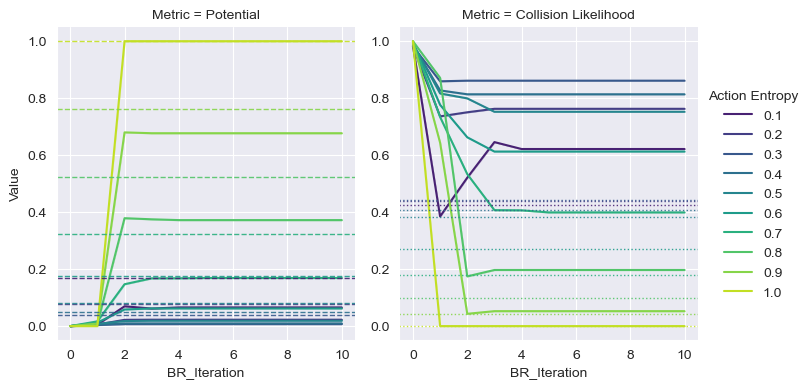

In [16]:
# Comparison of Global Feedback and Local Feedback Policies
# EXAMPLE 2:

import importlib
demo = importlib.import_module("2p_demo_class")
local_feedback_policy = demo.local_feedback_policy

#------------------------------------------------------------
Columns = 3
Rows = 3
T = 6
player_num = 2

change_entropy = [0.1*(i+1) for i in range(10)]

all_trial_results = []
global_baselines = {} 

targs_x0s = np.array([0,2,8,6])
#targs_x0s = np.array([0,2,3,1])

for action_entropy in change_entropy:
    
    test = Global_MDP(Rows,Columns,T,player_num)
    test.create_joint_MDP(action_entropy, targs_x0s)
    test.global_value_iteration()
    test.get_potential()
    test.get_collision_likelihood()

    global_baselines[round(action_entropy, 2)] = {
        'pot': test.potential_value,
        'coll': test.collision_likelihood
    }
    

    trial_data = local_feedback_policy(Rows, Columns, T, player_num, targs_x0s, action_entropy)

    all_trial_results.append(trial_data)


master_data = pd.concat(all_trial_results, ignore_index=True)


unique_entropies = [str(round(e, 2)) for e in change_entropy]
colors = sns.color_palette("viridis", len(unique_entropies))
entropy_to_color = dict(zip(unique_entropies, colors))

sns.set_style("darkgrid")

g = sns.relplot(
    data=master_data,
    kind="line",
    x="BR_Iteration", 
    y="Value", 
    hue="Action Entropy",
    hue_order=unique_entropies,
    col="Metric",
    height=4, 
    aspect=0.9,
    facet_kws={'sharey': False},
    palette=entropy_to_color #
)

for entropy_str, color in entropy_to_color.items():

    e_key = float(entropy_str)
    vals = global_baselines[e_key]
    

    g.axes[0, 0].axhline(vals['pot'], color=color, ls='--', alpha=0.9, linewidth=1)
    g.axes[0, 1].axhline(vals['coll'], color=color, ls=':', alpha=0.9, linewidth=1)

for ax in g.axes.flat:
    ax.set_ylim(-0.05, 1.05)

plt.show()

<Figure size 1000x500 with 0 Axes>

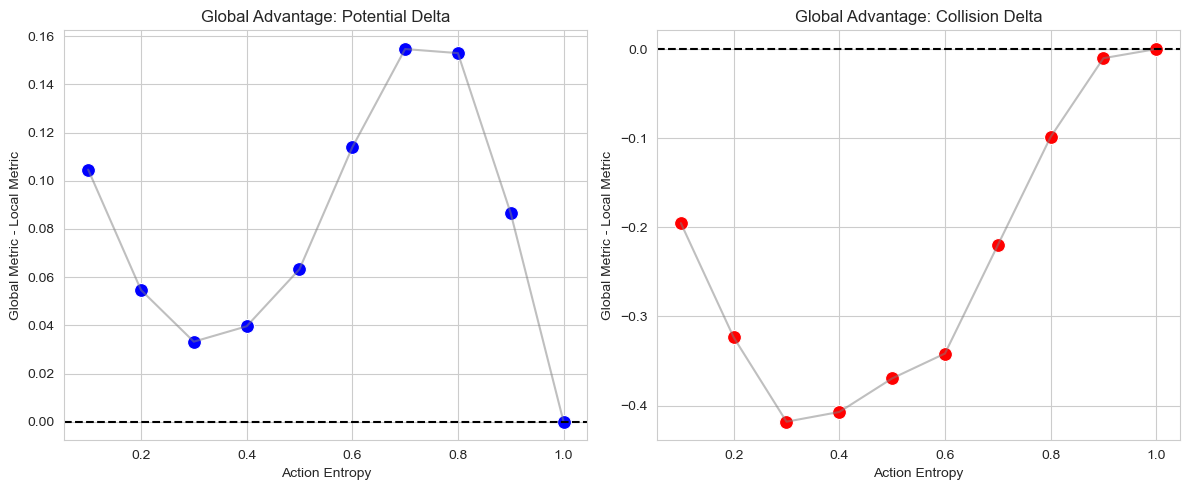

In [17]:
# 1. Filter master_data to get only the final BR iteration for each entropy/metric
final_iter_num = master_data['BR_Iteration'].max()
final_results = master_data[master_data['BR_Iteration'] == final_iter_num].copy()

# 2. Calculate the "Difference" (Global - Local)
diff_data = []

for entropy_str in unique_entropies:
    e_val = float(entropy_str)
    
    # Get Global values for this entropy
    global_pot = global_baselines[e_val]['pot']
    global_coll = global_baselines[e_val]['coll']
    
    # Get Local values for this entropy
    # (We take mean() in case there were multiple MC trials)
    local_pot = final_results[(final_results['Action Entropy'] == entropy_str) & 
                               (final_results['Metric'] == 'Potential')]['Value'].mean()
    local_coll = final_results[(final_results['Action Entropy'] == entropy_str) & 
                                (final_results['Metric'] == 'Collision Likelihood')]['Value'].mean()
    
    # Calculate Differences
    diff_data.append({'Action Entropy': e_val, 'Metric': 'Potential Delta', 'Difference': global_pot - local_pot})
    diff_data.append({'Action Entropy': e_val, 'Metric': 'Collision Delta', 'Difference': global_coll - local_coll})

df_diff = pd.DataFrame(diff_data)

# 3. Plot the Differences
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

# We create two subplots to see the gap clearly
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for i, metric in enumerate(['Potential Delta', 'Collision Delta']):
    subset = df_diff[df_diff['Metric'] == metric]
    sns.scatterplot(data=subset, x='Action Entropy', y='Difference', ax=axes[i], s=100, color='blue' if i==0 else 'red')
    sns.lineplot(data=subset, x='Action Entropy', y='Difference', ax=axes[i], alpha=0.5, color='gray')
    
    axes[i].axhline(0, color='black', linestyle='--') # The "Parity" line
    axes[i].set_title(f'Global Advantage: {metric}')
    axes[i].set_ylabel('Global Metric - Local Metric')

plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configuration ---
Columns, Rows = 3, 3
T = 6
player_num = 2
trials_per_entropy = 50 
change_entropy = [0.1 * (i + 1) for i in range(10)]
grid_size = Columns * Rows

all_data = []

# Loop 1: Entropy Levels
for action_entropy in change_entropy:
    print(f"Running simulation for entropy: {action_entropy:.1f}")
    
    for tr in range(trials_per_entropy):
        targs_x0s = np.random.choice(range(grid_size), size=player_num*2, replace=False)
        
        # 1. Global Metrics (Point of comparison)
        test = Global_MDP(Rows, Columns, T, player_num)
        test.create_joint_MDP(action_entropy, targs_x0s)
        test.global_value_iteration()
        test.get_potential()
        test.get_collision_likelihood()
        trial_df = local_feedback_policy(Rows, Columns, T, player_num, targs_x0s, action_entropy)
        

        trial_df['Trial_ID'] = tr
        trial_df['Global_Potential'] = test.potential_value
        trial_df['Global_Collision'] = test.collision_likelihood
        trial_df['Action Entropy'] = round(action_entropy, 2)
        
        all_data.append(trial_df)

# Combine everything
master_df = pd.concat(all_data, ignore_index=True)

Running simulation for entropy: 0.1
Starting joint MDP construction...
----------------------------------------
Target nodes: [2 8]
Starting nodes: [7 6]
Time to construct sparse joint P: 0.02 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 5 ...
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.14 seconds.
Starting joint MDP construction...
----------------------------------------
Target nodes: [1 5]
Starting nodes: [3 2]
Time to construct sparse joint P: 0.02 seconds.
----------------------------------------
Starting individual player best response.
Calculating for timestep 5 ...
Calculating for timestep 4 ...
Calculating for timestep 3 ...
Calculating for timestep 2 ...
Calculating for timestep 1 ...
Calculating for timestep 0 ...
Time to run the global policy: 0.12 seconds.
Star

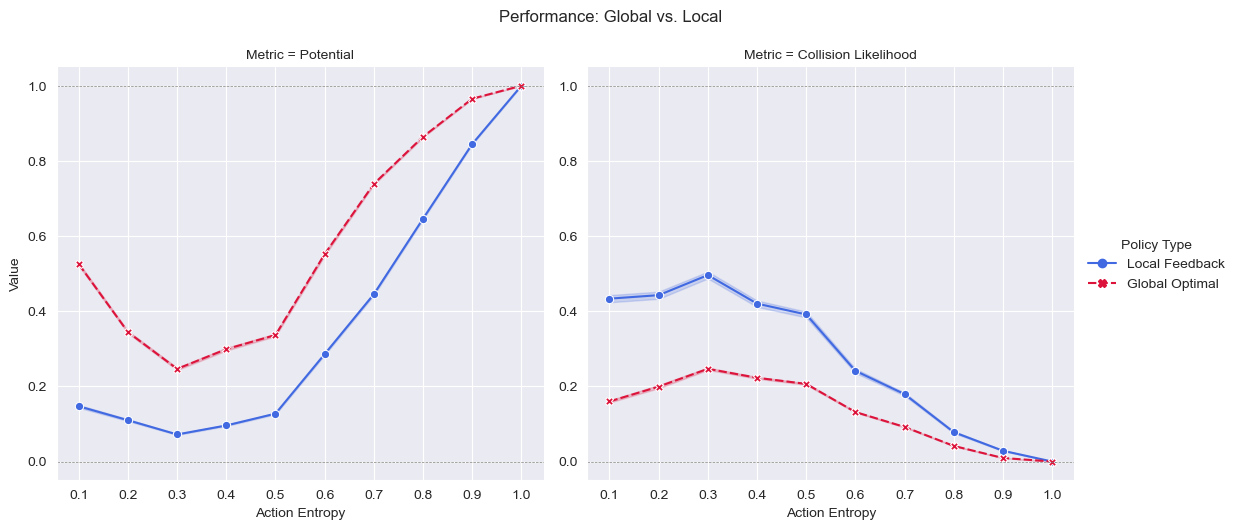

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate the "Converged" Local Policy (the final BR iteration)
final_br = master_df['BR_Iteration'].max()
converged_df = master_df[master_df['BR_Iteration'] == final_br].copy()

# 2. Reshape data so Global and Local metrics are in a single 'Value' column
# This allows Seaborn to handle the variance (shading) for both simultaneously
plot_rows = []

for _, row in converged_df.iterrows():
    # Local Metrics
    plot_rows.append({
        'Action Entropy': row['Action Entropy'],
        'Metric': row['Metric'],
        'Value': row['Value'],
        'Policy Type': 'Local Feedback'
    })
    # Global Potential (only need to add this once per trial)
    if row['Metric'] == 'Potential':
        plot_rows.append({
            'Action Entropy': row['Action Entropy'],
            'Metric': 'Potential',
            'Value': row['Global_Potential'],
            'Policy Type': 'Global Optimal'
        })
    # Global Collision
    else:
        plot_rows.append({
            'Action Entropy': row['Action Entropy'],
            'Metric': 'Collision Likelihood',
            'Value': row['Global_Collision'],
            'Policy Type': 'Global Optimal'
        })

df_final = pd.DataFrame(plot_rows)

# 3. Create the Variance Plots
sns.set_style("darkgrid")
g = sns.relplot(
    data=df_final,
    kind="line",
    x="Action Entropy",
    y="Value",
    hue="Policy Type",
    col="Metric",
    style="Policy Type",
    markers=True,
    errorbar=('ci', 95), # Shaded area = variance from randomized geometries
    facet_kws={'sharey': False},
    height=5,
    aspect=1.1,
    palette={'Local Feedback': 'royalblue', 'Global Optimal': 'crimson'}
)

# 4. Final Formatting
for ax in g.axes.flat:
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(change_entropy)
    ax.axhline(1.0, color='gray', lw=0.5, ls='--')
    ax.axhline(0.0, color='gray', lw=0.5, ls='--')

plt.suptitle("Performance: Global vs. Local", y=1.05)
plt.show()

In [3]:

#--------------MEMORY ALLOCATION STUFF---------------
# Go up to 6, go on one side to the other. how do both scale in the number of agents. High entropy 0.95, 
# ideally local policy scales less. memory time for both

# Run the 3x3 grid for increasing number of players, keep track of num of best responses before the best response (potential) 
# increases by less than 5%. Gives an idea empirically of how many br iterations before the iterative BR finishes. 
# Cite this in comp complexity. comparing 3 and 2, we are getting how many 2's needed for however many players. 
# IBR scales XXX in N, when does it converge. Whatever the dependency is, it is N X complexity of algorithm 2. 


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configuration ---
Columns, Rows = 3, 3
T = 6
player_num = 2
trials_per_entropy = 50 
change_entropy = [0.1 * (i + 1) for i in range(10)]
grid_size = Columns * Rows

all_data = []

def local_feedback_policy_test(Rows, Columns, T, player_num, targs_x0s, action_entropy):
    trial_data = pd.DataFrame({})
    # If the master loop handles trials, you might set this to 1 or 10 to save time
    MCs = 10 
    
    # 1. Define Base MDPs
    Ps = [mdp.transitions(Rows, Columns, p=action_entropy, with_stay=True) 
          for p in range(player_num)]
    S, _, A = Ps[0].shape
    
    targ_raw_inds = targs_x0s[:player_num]
    x_0s = targs_x0s[player_num:]

    # 2. FIX: Turn targets into sinks BEFORE any calculations
    # This ensures the denominator and numerator are comparing the same 'rules'
    for p in range(player_num):
        Ps[p][:, targ_raw_inds[p], 4] = np.zeros((S))
        Ps[p][targ_raw_inds[p], targ_raw_inds[p], 4] = 1.

    # 3. PRE-CALCULATION: Denominator (Independent Benchmark)
    indep_reach_probs_product = 1.0
    for p in range(player_num):
        V_indep, _ = vi.finite_reachability(Ps[p], T, targ_raw_inds[p])
        indep_reach_probs_product *= V_indep[x_0s[p], 0]

    time_start = time.time()
    for tr in range(MCs):
        # Initial policy setup
        pols = ut.scrolling_policy_flat(S, T+1)
        pis = [pols for _ in range(player_num)]
        xs = [mdp.occupancy(pis[p], Ps[p], x_0s[p]) for p in range(player_num)]
        
        potential, no_collisions, reach_reductions = [], [], []

        # Initial evaluation (Iteration 0)
        pot, no_col = game.potential(xs, targ_raw_inds)
        potential.append(pot)
        no_collisions.append(no_col)
        rr = pot / indep_reach_probs_product if indep_reach_probs_product > 1e-9 else 0.0
        reach_reductions.append(rr)
        
        # Iterative Best Response
        BR_iter = 5
        for ind in range(BR_iter):
            for p in range(player_num):
                opponent = (p+1) % player_num
                # Use Ps[p] instead of Ps[0] to be safe
                V, pi = vi.finite_reachability(Ps[p], T, targ_raw_inds[p], xs[opponent]) 
                pis[p] = pi  
                xs[p] = mdp.occupancy(pis[p], Ps[p], x_0s[p]) 
                
                # Check for both players before logging step
                if all(isinstance(x, np.ndarray) for x in xs):
                    pot, no_col = game.potential(xs, targ_raw_inds)
                    potential.append(pot)
                    no_collisions.append(no_col)
                    rr = pot / indep_reach_probs_product if indep_reach_probs_product > 1e-9 else 0.0
                    reach_reductions.append(rr)

        # Build DataFrame for this Monte Carlo trial
        num_metrics = len(potential)
        trial_data = pd.concat([trial_data, pd.DataFrame({
            'Trial': [tr] * num_metrics * 3, 
            'BR_Iteration': list(range(num_metrics)) * 3,
            'Value': potential + [1 - nc for nc in no_collisions] + reach_reductions,
            'Metric' : (['Potential'] * num_metrics + 
                        ['Collision Likelihood'] * num_metrics + 
                        ['Reach Reduction'] * num_metrics),
            'Action Entropy': [str(round(action_entropy, 2))] * num_metrics * 3
        })], ignore_index=True)
        
    time_end = time.time()
    return trial_data, (time_end - time_start)



In [4]:
a = np.array([1,2,3,4,5]) - np.array([0,4,2,5,1])
np.linalg.norm(a)

np.float64(4.795831523312719)